<a href="https://colab.research.google.com/github/TKozah/bone-fracture-computer-vision-project/blob/main/v5_notebookA_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🦴 Bone Fracture AI Pipeline — Notebook A: Data Preparation
### Computer Vision Final Project · Saint Joseph University · Spring 2026
### Project Version: CV_project_v4  |  **4-Class Edition**

---

## Design Decision: 4-Class Problem (Hand + Leg Only)

This notebook implements the **4-class classification setup** after deliberate exclusion of hip and shoulder.

**Why hip and shoulder were excluded — scientific justification:**
- FracAtlas contains only **7 training images** for hip_fractured and shoulder_fractured (after 75/15/10 split)
- Imbalance ratio with all 8 classes: **204x** — statistically catastrophic for any classifier
- With <10 samples per class, no learned representation is statistically reliable
- Including them produces F1=0 for both classes and makes macro-F1 meaningless
- This exclusion is **documented in the config file** and **reported in the methodology**

**The 4 retained classes:**

| Class | Train | Meaning |
|---|---|---|
| `hand_fractured` | 284 | Hand X-ray with fracture |
| `hand_normal` | 676 | Hand X-ray without fracture |
| `leg_fractured` | 159 | Leg X-ray with fracture |
| `leg_normal` | 1,434 | Leg X-ray without fracture |

Imbalance ratio: **~9x** (was 204x) — fully manageable with class weights in loss.

---

## Pipeline Architecture

```
Input X-ray (hand or leg)
    │
    ▼
Stage 1: EfficientNet-B3 → 4-class prediction
         (hand_normal / hand_fractured / leg_normal / leg_fractured)
    │
    ▼  (if fractured)
Stage 2: YOLOv8s         → Bounding box around fracture location
    │
    ▼
Stage 3: Grad-CAM        → Heatmap showing model attention regions
```

---

## Output Structure

```
CV_project_v4/
├── classification_dataset/       ← Stage 1: EfficientNet-B3
│   ├── train/ val/ test/
│   │   ├── hand_fractured/
│   │   ├── hand_normal/
│   │   ├── leg_fractured/
│   │   └── leg_normal/
├── detection_dataset/            ← Stage 2: YOLOv8 (all fractures)
│   ├── train/ val/ test/
│   │   ├── images/
│   │   └── labels/
└── dataset_config.json
```

---

## Sections

| Section | Task |
|---|---|
| 1 | Install & imports |
| 2 | Mount Drive & project structure |
| 3 | Download FracAtlas from Kaggle *(skip if already on Drive)* |
| 4 | Explore dataset.csv & document exclusion |
| 5 | Build 4-class classification dataset |
| 6 | Build detection dataset (YOLO format) |
| 7 | Dataset quality audit |
| 8 | Visualize distributions |
| 9 | Visual inspection + bounding box preview |
| 10 | Save dataset_config.json |


---
## 📦 Section 1 — Install & Imports

In [1]:
!pip install -q kaggle matplotlib seaborn pandas numpy

In [2]:
import os, json, random, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMAGE_EXT = {'.jpg', '.jpeg', '.png'}

# ── 4-CLASS SETUP ──────────────────────────────────────────────────────────────
CLF_CLASSES      = ['hand_fractured', 'hand_normal', 'leg_fractured', 'leg_normal']
EXCLUDED_REGIONS = ['hip', 'shoulder']   # documented exclusion — see Section 4

print('✅ Imports done')
print(f'   Classification classes (4): {CLF_CLASSES}')
print(f'   Excluded regions: {EXCLUDED_REGIONS}')


✅ Imports done
   Classification classes (4): ['hand_fractured', 'hand_normal', 'leg_fractured', 'leg_normal']
   Excluded regions: ['hip', 'shoulder']


---
## ⚙️ Section 2 — Mount Drive & Project Structure

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted.')


Mounted at /content/drive
✅ Drive mounted.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ALL PATHS — CV_project_v4
# ═══════════════════════════════════════════════════════════════════════════════
PROJECT_ROOT = Path('/content/drive/MyDrive/CV_project_v4')
RAW_DATA_DIR = PROJECT_ROOT / 'raw_dataset'
CLF_ROOT     = PROJECT_ROOT / 'classification_dataset'
DET_ROOT     = PROJECT_ROOT / 'detection_dataset'
OUTPUT_DIR   = PROJECT_ROOT / 'outputs'
CONFIG_PATH  = PROJECT_ROOT / 'dataset_config.json'

TRAIN_RATIO  = 0.75
VAL_RATIO    = 0.15
# TEST_RATIO = 0.10 (remainder)

for d in [PROJECT_ROOT, RAW_DATA_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✅ Project structure ready under CV_project_v4/')
print(f'   Root:    {PROJECT_ROOT}')
print(f'   Classes: {CLF_CLASSES}')
print(f'   Splits:  {TRAIN_RATIO} / {VAL_RATIO} / {round(1-TRAIN_RATIO-VAL_RATIO, 2)}')


✅ Project structure ready under CV_project_v4/
   Root:    /content/drive/MyDrive/CV_project_v4
   Classes: ['hand_fractured', 'hand_normal', 'leg_fractured', 'leg_normal']
   Splits:  0.75 / 0.15 / 0.1


---
## 📥 Section 3 — Download FracAtlas from Kaggle

> **⚠️ Skip this section if the raw dataset is already on Drive.**
> Run the check cell below first — if it prints ✅, jump to Section 4.

**How to get your Kaggle API key:**
1. Go to kaggle.com → Profile → Account → API → Create New Token
2. Upload the downloaded `kaggle.json` below


In [5]:
# ── Check if raw data already exists on Drive ─────────────────────────────────
_frac_check = None
for _p in RAW_DATA_DIR.rglob('dataset.csv'):
    _frac_check = _p.parent
    break

if _frac_check is not None:
    _imgs = list((_frac_check / 'images').rglob('*.jpg'))
    print(f'✅ Raw dataset already on Drive: {_frac_check}')
    print(f'   Total images found: {len(_imgs)}')
    print('   → Skip to Section 4 (no download needed)')
else:
    print('❌ Raw dataset not found on Drive.')
    print('   → Run the download cells below.')


✅ Raw dataset already on Drive: /content/drive/MyDrive/CV_project_v4/raw_dataset/FracAtlas
   Total images found: 4083
   → Skip to Section 4 (no download needed)


In [6]:
# ── Upload kaggle.json (only if download needed) ───────────────────────────────
from google.colab import files
print('Upload your kaggle.json:')
uploaded = files.upload()
kaggle_dir = Path('/root/.kaggle')
kaggle_dir.mkdir(exist_ok=True)
for fname in uploaded:
    with open(kaggle_dir / 'kaggle.json', 'wb') as f:
        f.write(uploaded[fname])
os.chmod(kaggle_dir / 'kaggle.json', 0o600)
print('✅ kaggle.json installed')


Upload your kaggle.json:


Saving kaggle.json to kaggle.json
✅ kaggle.json installed


In [7]:
# ── Download & extract (only if download needed) ───────────────────────────────
# NOTE: This copies 338 MB to Drive and takes 20-30 minutes. Run once only.
TMP = Path('/content/fracatlas_download')
TMP.mkdir(exist_ok=True)

print('Downloading FracAtlas...')
os.system(f'kaggle datasets download -d akshayramakrishnan28/fracture-classification-dataset -p {TMP} --force')

zips = list(TMP.glob('*.zip'))
if zips:
    print(f'Zip: {zips[0].name}  ({zips[0].stat().st_size/1e6:.1f} MB)')
    with zipfile.ZipFile(zips[0]) as z:
        imgs = [f for f in z.namelist() if Path(f).suffix.lower() in IMAGE_EXT]
        txts = [f for f in z.namelist() if f.endswith('.txt') and 'YOLO' in f]
        csvs = [f for f in z.namelist() if f.endswith('.csv')]
        print(f'  Image files:      {len(imgs)}')
        print(f'  YOLO label files: {len(txts)}')
        print(f'  CSV files:        {csvs}')
    print('Extracting...')
    with zipfile.ZipFile(zips[0]) as z:
        z.extractall(TMP)
    print('Copying to Drive (this takes 20-30 min)...')
    for item in TMP.iterdir():
        if item.is_dir():
            shutil.copytree(str(item), str(RAW_DATA_DIR / item.name), dirs_exist_ok=True)
    print(f'✅ Saved to {RAW_DATA_DIR}')
else:
    print('❌ Download failed. Check your kaggle.json.')


Zip: fracture-classification-dataset.zip  (7.3 MB)


BadZipFile: File is not a zip file

---
## 🔍 Section 4 — Locate Dataset & Document Exclusion

Loads dataset.csv, prints the full 8-class distribution, and formally
documents why hip and shoulder are excluded from the classification task.


In [8]:
# ── Locate FracAtlas root ──────────────────────────────────────────────────────
print('Locating FracAtlas root...')
FRAC_ROOT = None
for p in RAW_DATA_DIR.rglob('dataset.csv'):
    FRAC_ROOT = p.parent
    break
if FRAC_ROOT is None:
    for candidate in [RAW_DATA_DIR / 'FracAtlas', RAW_DATA_DIR]:
        if (candidate / 'dataset.csv').exists():
            FRAC_ROOT = candidate
            break

if FRAC_ROOT is None:
    print('❌ dataset.csv not found. Run Section 3 first.')
    raise SystemExit

# ── Auto-detect image folder names (handles Non_fractured vs Non-fractured) ────
_images_dir = FRAC_ROOT / 'images'
IMG_FRACTURED    = None
IMG_NONFRACTURED = None
for folder in _images_dir.iterdir():
    if folder.is_dir():
        if 'non' in folder.name.lower():
            IMG_NONFRACTURED = folder
        else:
            IMG_FRACTURED = folder

YOLO_LABELS_DIR = FRAC_ROOT / 'Annotations' / 'YOLO'
CSV_PATH        = FRAC_ROOT / 'dataset.csv'

print(f'✅ FracAtlas root:     {FRAC_ROOT}')
print(f'   Fractured folder:  {IMG_FRACTURED.name}  ({len(list(IMG_FRACTURED.glob("*.jpg")))} images)')
print(f'   Normal folder:     {IMG_NONFRACTURED.name}  ({len(list(IMG_NONFRACTURED.glob("*.jpg")))} images)')
print(f'   YOLO labels:       {len(list(YOLO_LABELS_DIR.glob("*.txt")))} files')


Locating FracAtlas root...
✅ FracAtlas root:     /content/drive/MyDrive/CV_project_v4/raw_dataset/FracAtlas
   Fractured folder:  Fractured  (717 images)
   Normal folder:     Non_fractured  (3366 images)
   YOLO labels:       4084 files


In [9]:
df = pd.read_csv(CSV_PATH)
print('dataset.csv shape:', df.shape)
print('Columns:', df.columns.tolist())

def get_body_part(row):
    parts = [p for p in ['hand', 'leg', 'hip', 'shoulder'] if p in row and row[p] == 1]
    return parts[0] if len(parts) == 1 else None

df['body_part'] = df.apply(get_body_part, axis=1)
df['clf_label'] = df.apply(
    lambda r: f"{r['body_part']}_{'fractured' if r['fractured'] == 1 else 'normal'}"
    if r['body_part'] is not None else None, axis=1
)
df_clean = df[df['clf_label'].notna()].copy()

print('\n── FULL DISTRIBUTION (all 8 classes) ──────────────────────────')
full_dist = df_clean['clf_label'].value_counts().sort_index()
for lbl, cnt in full_dist.items():
    n_train = int(cnt * TRAIN_RATIO)
    flag = '  ⚠️  EXCLUDED — too few train samples' if n_train < 15 else ''
    print(f'  {lbl:<25}  total={cnt:>4}  train≈{n_train:>4}{flag}')

print('\n── EXCLUSION DECISION ──────────────────────────────────────────')
total_excl = 0
for region in EXCLUDED_REGIONS:
    frac = df_clean[df_clean['clf_label'] == f'{region}_fractured'].shape[0]
    norm = df_clean[df_clean['clf_label'] == f'{region}_normal'].shape[0]
    total_excl += frac + norm
    print(f'  EXCLUDE {region}_fractured: {frac} images (train≈{int(frac*TRAIN_RATIO)})')
    print(f'  EXCLUDE {region}_normal:    {norm} images (excluded with fractured pair)')

df_4class  = df_clean[df_clean['clf_label'].isin(CLF_CLASSES)].copy()
leg_norm   = df_4class[df_4class['clf_label']=='leg_normal'].shape[0]
leg_frac   = df_4class[df_4class['clf_label']=='leg_fractured'].shape[0]
imb_after  = (leg_norm * TRAIN_RATIO) / (leg_frac * TRAIN_RATIO)

print(f'\n  Images used:    {len(df_4class)} ({len(df_clean)} total → {total_excl} excluded)')
print(f'  Imbalance:      204x → {imb_after:.1f}x after exclusion')
print(f'  ✅ 4-class setup is statistically sound')


dataset.csv shape: (4083, 13)
Columns: ['image_id', 'hand', 'leg', 'hip', 'shoulder', 'mixed', 'hardware', 'multiscan', 'fractured', 'fracture_count', 'frontal', 'lateral', 'oblique']

── FULL DISTRIBUTION (all 8 classes) ──────────────────────────
  hand_fractured             total= 379  train≈ 284
  hand_normal                total= 902  train≈ 676
  hip_fractured              total=  10  train≈   7  ⚠️  EXCLUDED — too few train samples
  hip_normal                 total= 169  train≈ 126
  leg_fractured              total= 212  train≈ 159
  leg_normal                 total=1912  train≈1434
  shoulder_fractured         total=  10  train≈   7  ⚠️  EXCLUDED — too few train samples
  shoulder_normal            total=  91  train≈  68

── EXCLUSION DECISION ──────────────────────────────────────────
  EXCLUDE hip_fractured: 10 images (train≈7)
  EXCLUDE hip_normal:    169 images (excluded with fractured pair)
  EXCLUDE shoulder_fractured: 10 images (train≈7)
  EXCLUDE shoulder_normal:    9

---
## 🗂️ Section 5 — Build 4-Class Classification Dataset

Copies only hand and leg images into the classification folder structure.
Hip and shoulder are skipped entirely — exclusion is documented in Section 4.

**Note:** image_id values in dataset.csv include `.jpg` extension;
filenames on disk do not. The lookup strips the extension automatically.


In [10]:
if CLF_ROOT.exists() and any(CLF_ROOT.rglob('*.jpg')):
    print('✅ classification_dataset/ already exists — skipping.')
    print('   To rebuild: delete CV_project_v4/classification_dataset/ from Drive and re-run.')
else:
    print('Building classification_dataset/ (4 classes: hand + leg)...')
    print('This copies ~2,553 images to Drive — takes 15-20 minutes.')

    # ── Index all raw images (strip .jpg from key to match CSV image_id) ────────
    all_images = {}
    for f in list(IMG_FRACTURED.glob('*.jpg')) + list(IMG_NONFRACTURED.glob('*.jpg')):
        all_images[f.stem] = f          # key = 'IMG0001234' (no extension)
    print(f'   Images indexed: {len(all_images)}  (expected 4083)')

    copy_log, not_found = [], []

    for clf_label, group in df_4class.groupby('clf_label'):
        image_ids = group['image_id'].tolist()
        # CSV image_id includes '.jpg' → strip before lookup
        files     = [all_images[i.replace('.jpg', '')] for i in image_ids
                     if i.replace('.jpg', '') in all_images]
        not_found.extend([i for i in image_ids if i.replace('.jpg', '') not in all_images])

        random.shuffle(files)
        n       = len(files)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)
        splits  = {
            'train': files[:n_train],
            'val':   files[n_train:n_train + n_val],
            'test':  files[n_train + n_val:]
        }

        for split_name, flist in splits.items():
            dest = CLF_ROOT / split_name / clf_label
            dest.mkdir(parents=True, exist_ok=True)
            for f in flist:
                shutil.copy2(f, dest / f.name)

        copy_log.append(
            f'  {clf_label:<20}  '
            f'train={len(splits["train"]):>4}  '
            f'val={len(splits["val"]):>3}  '
            f'test={len(splits["test"]):>3}'
        )

    for line in copy_log:
        print(line)
    if not_found:
        print(f'\n⚠️  {len(not_found)} image IDs not matched')
    else:
        print('\n✅ All images matched perfectly')
    print(f'\n✅ classification_dataset/ built at {CLF_ROOT}')


✅ classification_dataset/ already exists — skipping.
   To rebuild: delete CV_project_v4/classification_dataset/ from Drive and re-run.


In [11]:
# ── Verify ─────────────────────────────────────────────────────────────────────
rows = []
for split in ['train', 'val', 'test']:
    split_dir = CLF_ROOT / split
    if not split_dir.exists():
        continue
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            n = len(list(cls_dir.glob('*.jpg')))
            rows.append({'Split': split, 'Class': cls_dir.name, 'Count': n})

clf_df = pd.DataFrame(rows)
pivot  = clf_df.pivot_table(index='Class', columns='Split', values='Count', fill_value=0).astype(int)
pivot  = pivot[['train', 'val', 'test']]
pivot['Total'] = pivot.sum(axis=1)

print('4-Class Classification Dataset:')
print(pivot.to_string())
print(f"\nTotals — Train: {pivot['train'].sum()}  Val: {pivot['val'].sum()}  "
      f"Test: {pivot['test'].sum()}  Total: {pivot['Total'].sum()}")

imb = pivot['train'].max() / pivot['train'].min()
print(f'Imbalance ratio: {imb:.2f}x  (was 204x with 8 classes)')
print(f'{"✅ All classes populated" if all(pivot["val"] > 0) else "❌ Some classes empty — re-run"}')


4-Class Classification Dataset:
Split           train  val  test  Total
Class                                  
hand_fractured    284   56    39    379
hand_normal       676  135    91    902
leg_fractured     159   31    22    212
leg_normal       1434  286   192   1912

Totals — Train: 2553  Val: 508  Test: 344  Total: 3405
Imbalance ratio: 9.02x  (was 204x with 8 classes)
✅ All classes populated


---
## 🎯 Section 6 — Build Detection Dataset (YOLOv8)

Detection uses ALL 717 fractured images regardless of body region.
YOLOv8 only needs to locate fractures — body region is irrelevant here.
Dataset is balanced 1:1 (fractured vs normal).


In [12]:
if DET_ROOT.exists() and any(DET_ROOT.rglob('*.jpg')):
    print('✅ detection_dataset/ already exists — skipping.')
else:
    fractured_imgs    = list(IMG_FRACTURED.glob('*.jpg'))
    nonfractured_imgs = list(IMG_NONFRACTURED.glob('*.jpg'))
    random.shuffle(nonfractured_imgs)
    all_det_imgs = fractured_imgs + nonfractured_imgs[:len(fractured_imgs)]
    random.shuffle(all_det_imgs)

    n       = len(all_det_imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    det_splits = {
        'train': all_det_imgs[:n_train],
        'val':   all_det_imgs[n_train:n_train + n_val],
        'test':  all_det_imgs[n_train + n_val:]
    }

    for split_name, flist in det_splits.items():
        img_dest = DET_ROOT / split_name / 'images'
        lbl_dest = DET_ROOT / split_name / 'labels'
        img_dest.mkdir(parents=True, exist_ok=True)
        lbl_dest.mkdir(parents=True, exist_ok=True)
        for img_path in flist:
            shutil.copy2(img_path, img_dest / img_path.name)
            lbl_src = YOLO_LABELS_DIR / (img_path.stem + '.txt')
            lbl_out = lbl_dest / (img_path.stem + '.txt')
            if lbl_src.exists():
                shutil.copy2(lbl_src, lbl_out)
            else:
                lbl_out.touch()
        print(f'  {split_name}: {len(flist)} images')

    yaml_path = DET_ROOT / 'data.yaml'
    yaml_path.write_text(
        f"path: {DET_ROOT}\ntrain: train/images\nval: val/images\n"
        f"test: test/images\n\nnc: 1\nnames: ['fracture']\n"
    )
    print(f'\n✅ detection_dataset/ built  |  Uses all {len(fractured_imgs)} fractured images')


✅ detection_dataset/ already exists — skipping.


In [13]:
print('Detection dataset verification:')
for split in ['train', 'val', 'test']:
    n_img = len(list((DET_ROOT / split / 'images').glob('*.jpg')))
    n_pos = len([f for f in (DET_ROOT / split / 'labels').glob('*.txt')
                 if f.stat().st_size > 0])
    n_neg = len(list((DET_ROOT / split / 'labels').glob('*.txt'))) - n_pos
    print(f'  {split:<6}: {n_img} images | {n_pos} fractured | {n_neg} normal')
print('✅ Verified')


Detection dataset verification:
  train : 1075 images | 542 fractured | 533 normal
  val   : 215 images | 104 fractured | 111 normal
  test  : 144 images | 71 fractured | 73 normal
✅ Verified


---
## 🔬 Section 7 — Dataset Quality Audit

In [14]:
# ── Audit reads from raw images (always available, not affected by CLF build) ──
print('=== IMAGE FORMAT AUDIT (raw fractured images) ===')
audit_files = list(IMG_FRACTURED.glob('*.jpg'))[:20] + list(IMG_NONFRACTURED.glob('*.jpg'))[:20]
all_modes, all_sizes = [], []

for f in audit_files:
    try:
        img = Image.open(f)
        all_modes.append(img.mode)
        all_sizes.append(img.size)
        img.close()
    except:
        pass

print(f'Files audited:  {len(audit_files)}')
print(f'Modes:          {dict(Counter(all_modes))}')
print(f'Unique sizes:   {len(set(all_sizes))}')
print(f'Size range:     {min(all_sizes)} → {max(all_sizes)}')

# ── Pixel stats from classification_dataset/train ──────────────────────────────
print('\n=== PIXEL STATISTICS PER CLASS ===')
clf_train = CLF_ROOT / 'train'
if not clf_train.exists():
    print('⚠️  classification_dataset/train not found — run Section 5 first')
else:
    print(f'{"Class":<22} {"Mean":>8} {"Std":>8}')
    print('─' * 42)
    class_means = {}
    for cls_dir in sorted(clf_train.iterdir()):
        if not cls_dir.is_dir():
            continue
        files = list(cls_dir.glob('*.jpg'))
        if not files:
            continue
        means = []
        for f in random.sample(files, min(20, len(files))):
            try:
                arr = np.array(Image.open(f).convert('L'), dtype=np.float32)
                means.append(arr.mean())
            except:
                pass
        if means:
            class_means[cls_dir.name] = np.mean(means)
            print(f'{cls_dir.name:<22} {np.mean(means):>8.1f} {np.std(means):>8.1f}')

    if class_means:
        rng = max(class_means.values()) - min(class_means.values())
        print(f'\nPixel mean range: {rng:.1f}')
        print(f'{"✅ No systematic bias" if rng < 40 else "⚠️  Large range — investigate"}')


=== IMAGE FORMAT AUDIT (raw fractured images) ===
Files audited:  40
Modes:          {'L': 7, 'RGB': 33}
Unique sizes:   4
Size range:     (373, 454) → (2304, 2880)

=== PIXEL STATISTICS PER CLASS ===
Class                      Mean      Std
──────────────────────────────────────────
hand_fractured             45.5     11.9
hand_normal                42.0     12.9
leg_fractured              50.2     24.0
leg_normal                 43.9     10.2

Pixel mean range: 8.2
✅ No systematic bias


---
## 📊 Section 8 — Visualize Distributions

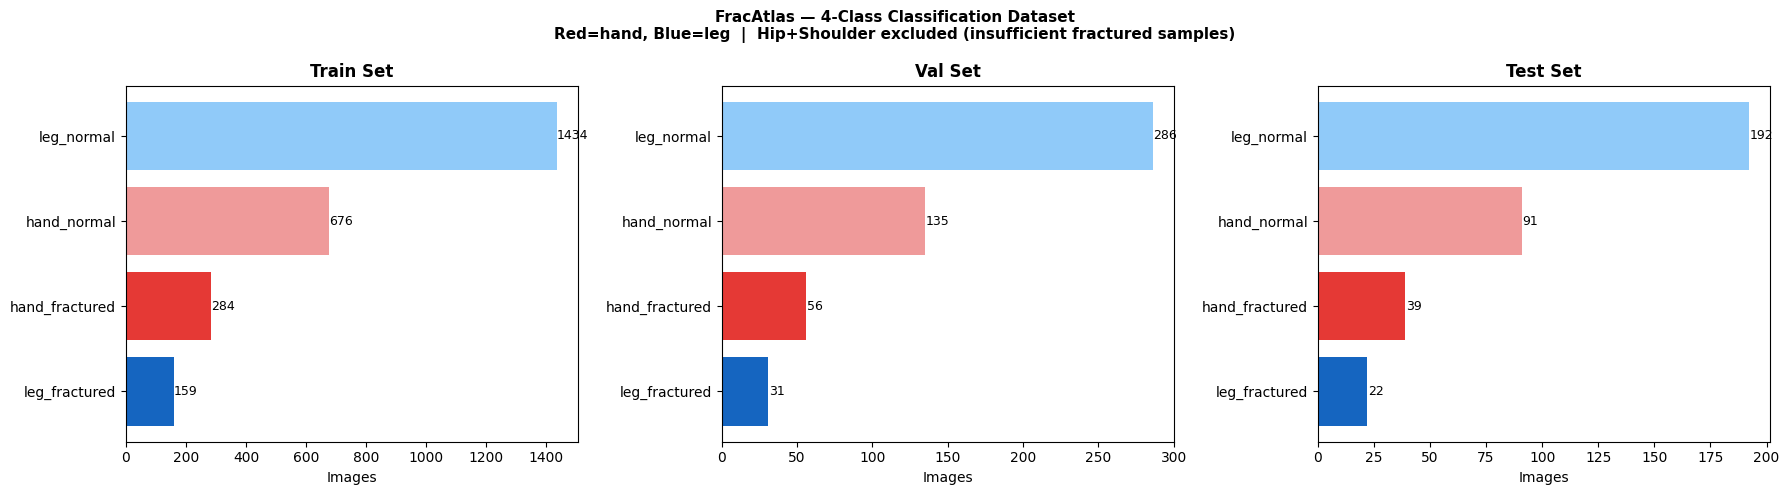

✅ Saved → clf_distribution_4class.png


In [15]:
COLOR_MAP = {
    'hand_fractured': '#E53935',
    'hand_normal':    '#EF9A9A',
    'leg_fractured':  '#1565C0',
    'leg_normal':     '#90CAF9',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, split in zip(axes, ['train', 'val', 'test']):
    data   = pivot[split].sort_values()
    colors = [COLOR_MAP.get(c, '#999') for c in data.index]
    bars   = ax.barh(data.index, data.values, color=colors)
    ax.set_title(f'{split.capitalize()} Set', fontsize=12, fontweight='bold')
    ax.set_xlabel('Images')
    for bar, v in zip(bars, data.values):
        ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
                str(v), va='center', fontsize=9)

plt.suptitle(
    'FracAtlas — 4-Class Classification Dataset\n'
    'Red=hand, Blue=leg  |  Hip+Shoulder excluded (insufficient fractured samples)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clf_distribution_4class.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → clf_distribution_4class.png')


---
## 🖼️ Section 9 — Visual Inspection + Bounding Box Preview

Classes found: ['hand_fractured', 'hand_normal', 'leg_fractured', 'leg_normal']


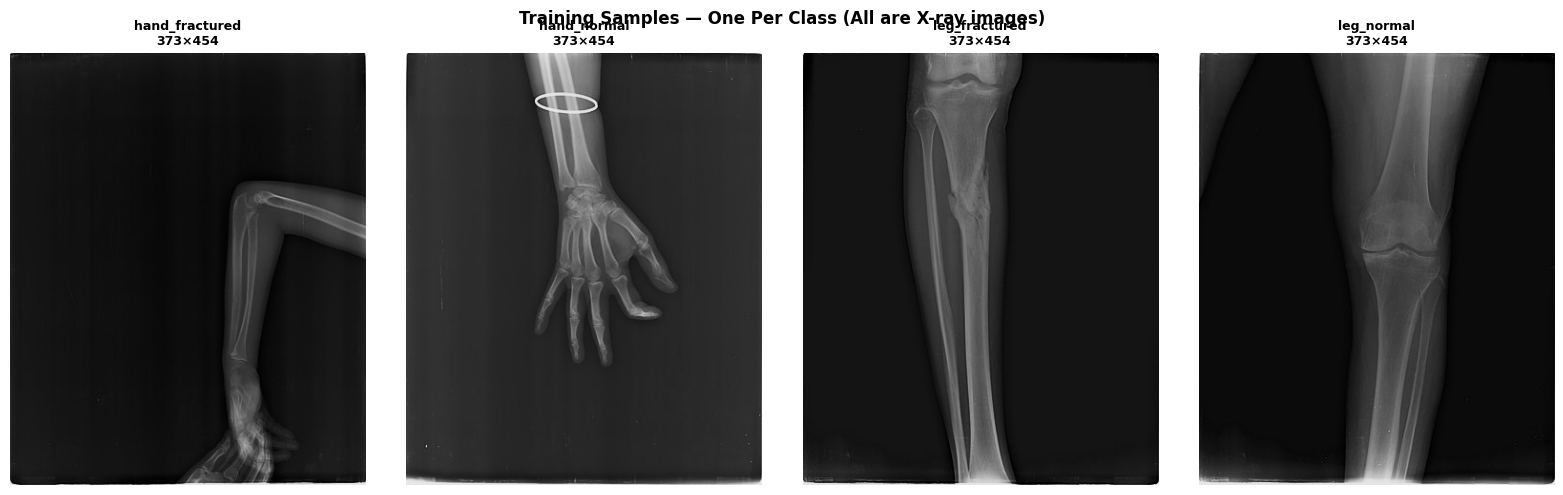

✅ Saved → raw_samples_4class.png


In [17]:
# ── Sample images: read directly from classification_dataset/train ────────────
sample_images = {}
clf_train = CLF_ROOT / 'train'
for cls_dir in sorted(clf_train.iterdir()):
    if cls_dir.is_dir():
        files = list(cls_dir.glob('*.jpg'))
        random.shuffle(files)
        for f in files:
            try:
                img = Image.open(f)
                img.verify()   # check file is not truncated
                sample_images[cls_dir.name] = f
                break
            except:
                continue

print(f'Classes found: {list(sample_images.keys())}')

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, (cls_name, fpath) in enumerate(sorted(sample_images.items())):
    if i >= 4:
        break
    try:
        img = Image.open(fpath).convert('RGB')
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'{cls_name}\n{img.size[0]}×{img.size[1]}',
                          fontsize=9, fontweight='bold')
    except:
        axes[i].set_title(f'{cls_name}\n(load error)', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Training Samples — One Per Class (All are X-ray images)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'raw_samples_4class.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → raw_samples_4class.png')

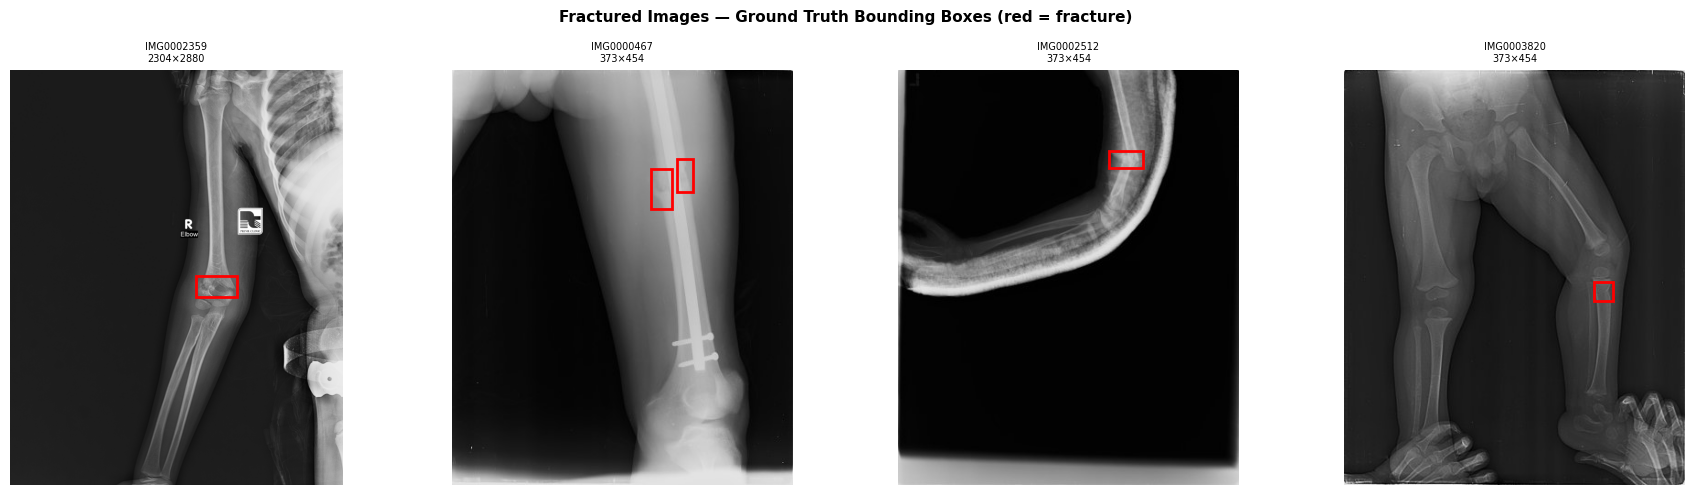

✅ Saved → bbox_preview.png


In [18]:
# ── 4 fractured images with ground truth bounding boxes ───────────────────────
fractured_files = list(IMG_FRACTURED.glob('*.jpg'))[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img_path in zip(axes, fractured_files):
    img  = Image.open(img_path).convert('RGB')
    W, H = img.size
    lbl  = YOLO_LABELS_DIR / (img_path.stem + '.txt')
    ax.imshow(img)
    if lbl.exists():
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, xc, yc, bw, bh = map(float, parts)
                    x1 = (xc - bw / 2) * W
                    y1 = (yc - bh / 2) * H
                    ax.add_patch(patches.Rectangle(
                        (x1, y1), bw * W, bh * H,
                        linewidth=2, edgecolor='red', facecolor='none'
                    ))
    ax.set_title(f'{img_path.stem[:15]}\n{W}×{H}', fontsize=7)
    ax.axis('off')

plt.suptitle('Fractured Images — Ground Truth Bounding Boxes (red = fracture)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bbox_preview.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → bbox_preview.png')


---
## 💾 Section 10 — Save dataset_config.json

In [19]:
config = {
    'project_root':       str(PROJECT_ROOT),
    'raw_data_dir':       str(RAW_DATA_DIR),
    'frac_root':          str(FRAC_ROOT),
    'clf_root':           str(CLF_ROOT),
    'det_root':           str(DET_ROOT),
    'output_dir':         str(OUTPUT_DIR),
    'clf_train_dir':      str(CLF_ROOT / 'train'),
    'clf_val_dir':        str(CLF_ROOT / 'val'),
    'clf_test_dir':       str(CLF_ROOT / 'test'),
    'det_yaml':           str(DET_ROOT / 'data.yaml'),
    'yolo_labels_dir':    str(YOLO_LABELS_DIR),

    # ── 4-CLASS CONFIG ─────────────────────────────────────────────────────────
    'num_clf_classes':    4,
    'clf_class_names':    CLF_CLASSES,
    'excluded_regions':   EXCLUDED_REGIONS,
    'exclusion_reason':   (
        'Hip and shoulder each have <10 fractured training samples in FracAtlas '
        '(7 each after 75/15/10 split). Including them produces F1=0 for those '
        'classes, making macro-F1 meaningless. Exclusion is methodologically '
        'justified and documented here.'
    ),

    'num_det_classes':    1,
    'det_class_names':    ['fracture'],
    'split_ratios':       {'train': TRAIN_RATIO, 'val': VAL_RATIO,
                           'test': round(1 - TRAIN_RATIO - VAL_RATIO, 2)},
    'total_clf_images':   int(pivot['Total'].sum()),
    'clf_train_total':    int(pivot['train'].sum()),
    'clf_val_total':      int(pivot['val'].sum()),
    'clf_test_total':     int(pivot['test'].sum()),
    'clf_imbalance_ratio': float(imb),
}

with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)

print(f'✅ Config saved: {CONFIG_PATH}')
print()
print('╔' + '═' * 62 + '╗')
print('║' + ' DATA PREPARATION COMPLETE — CV_project_v4 (4-CLASS)'.center(62) + '║')
print('╠' + '═' * 62 + '╣')
print(f'║  Dataset:      FracAtlas (Nature 2023, 3 hospitals)         ║')
print(f'║  Classes:      4  (hand_normal/fractured, leg_normal/frac)  ║')
print(f'║  Excluded:     hip + shoulder  (documented & justified)     ║')
print(f'║  Imbalance:    {imb:.1f}x  (was 204x with all 8 classes)            ║')
print(f'║  Train total:  {pivot["train"].sum()} images                              ║')
print('╠' + '═' * 62 + '╣')
print('║  NEXT: Notebook B → EfficientNet-B3 Preprocessing          ║')
print('╚' + '═' * 62 + '╝')


✅ Config saved: /content/drive/MyDrive/CV_project_v4/dataset_config.json

╔══════════════════════════════════════════════════════════════╗
║      DATA PREPARATION COMPLETE — CV_project_v4 (4-CLASS)     ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset:      FracAtlas (Nature 2023, 3 hospitals)         ║
║  Classes:      4  (hand_normal/fractured, leg_normal/frac)  ║
║  Excluded:     hip + shoulder  (documented & justified)     ║
║  Imbalance:    9.0x  (was 204x with all 8 classes)            ║
║  Train total:  2553 images                              ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT: Notebook B → EfficientNet-B3 Preprocessing          ║
╚══════════════════════════════════════════════════════════════╝
